# Decision Tree 🪾

The decision tree is a widely used model for classification and regression problems.

In scikit-learn, decision trees are implemented as **`DecisionTreeRegressor`** and **`DecisionTreeClassifier`**.  
Scikit-learn supports only **`pre-pruning`** (also known as early stopping) for decision trees.


In [63]:
### import libs
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

%matplotlib inline
import numpy as np

# Decision Tree Classifier 🪾

---
## 🪻 Iris
- Load the iris dataset provided by sklearn.
- Understand this dataset has categorical target not numerical
- Split the data into training and testing sets.

### import data, tree module, and fit

In [64]:
from sklearn.datasets import load_iris

iris = load_iris()

In [65]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=100
)

In [67]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### check score

In [68]:
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

1.0
0.9666666666666667


In [69]:
print("Accuracy on the training subset: {:.3f}".format(model.score(X_train, y_train)))
print("Accuracy on the test subset: {:.3f}".format(model.score(X_test, y_test)))

Accuracy on the training subset: 1.000
Accuracy on the test subset: 0.967


In [70]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)  # model result
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[11  0  0]
 [ 0  5  1]
 [ 0  0 13]]


### Decision Tree visualiztion


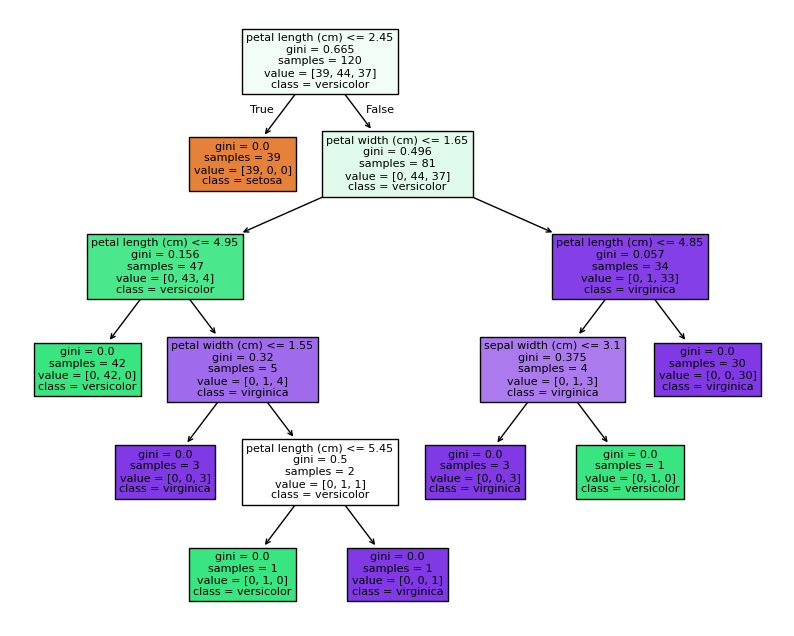

In [71]:
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 8))
plot_tree(
    model, class_names=iris.target_names, feature_names=iris.feature_names, filled=True
)
plt.show()

### Remodel using max_depth=10

In [72]:
model2 = DecisionTreeClassifier(
    max_depth=2
)  # previously model=DecisionTreeClassifier()
result = model2.fit(X_train, y_train)
result

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


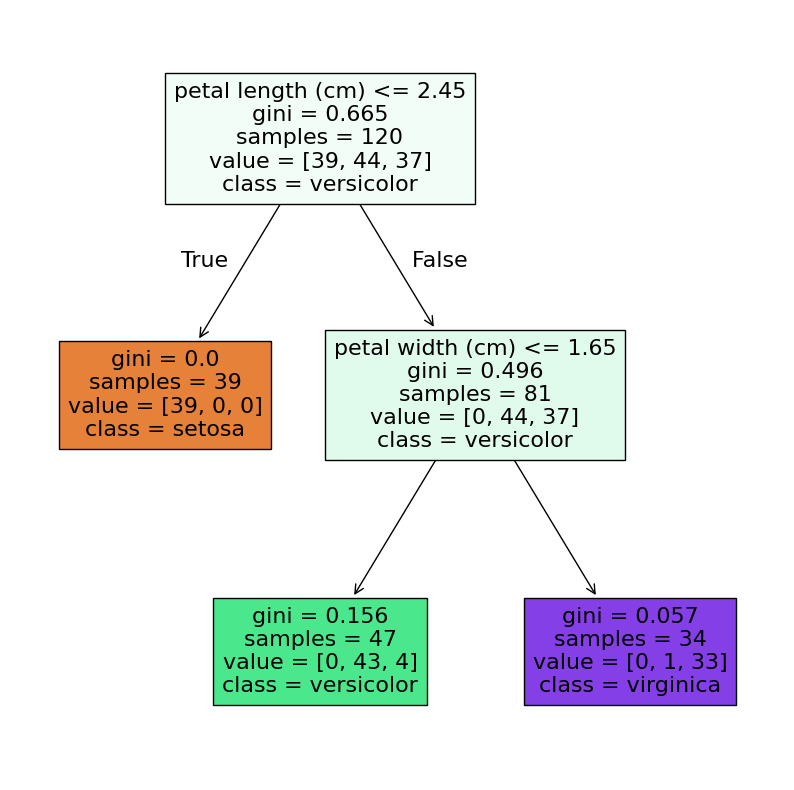

In [73]:
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 10))
plot_tree(
    model2,
    class_names=iris.target_names,
    feature_names=iris.feature_names,
    filled=True,
)
plt.show()

In [74]:
print(model.feature_importances_)
print(model2.feature_importances_)

[0.         0.01880092 0.58591345 0.39528563]
[0.         0.         0.56131756 0.43868244]


In [75]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

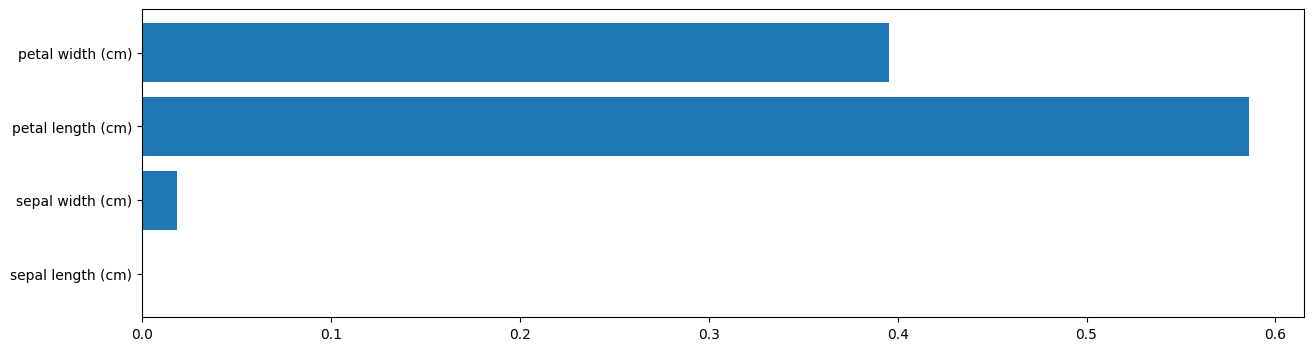

In [76]:
n_features = iris.data.shape[1]
plt.figure(figsize=(15, 4))
plt.barh(np.arange(4), model.feature_importances_)
plt.yticks(np.arange(4), iris.feature_names)
plt.show()

---
## 🏥 Breast Cancer

### Creating the Decision Tree Model

- Create a DecisionTreeClassifier for classification.
- Evaluate the model on both the training and testing datasets.

In [77]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

In [78]:
cancer.data.shape

(569, 30)

In [79]:
cancer.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

### Solving Overfitting

- You can prevent overfitting by specifying one of the following hyperparameters: `max_depth`, `max_leaf_nodes`, or `min_samples_leaf`.
- Setting these parameters helps to control the complexity of the decision tree model.

[for more info, read doc](https://scikit-learn.org/1.5/modules/generated/sklearn.tree.DecisionTreeClassifier.html)

In [80]:
cancer.target_names

array(['malignant', 'benign'], dtype='<U9')

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=100
)

In [82]:
tree = DecisionTreeClassifier(max_depth=20)
tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [83]:
tree.score(X_test, y_test)

0.9440559440559441

Accuracy on the training subset: 0.925 test subset: 0.916
Accuracy on the training subset: 0.946 test subset: 0.951
Accuracy on the training subset: 0.972 test subset: 0.937
Accuracy on the training subset: 0.986 test subset: 0.944
Accuracy on the training subset: 0.993 test subset: 0.937
Accuracy on the training subset: 1.000 test subset: 0.937
Accuracy on the training subset: 1.000 test subset: 0.937
Accuracy on the training subset: 1.000 test subset: 0.937
Accuracy on the training subset: 1.000 test subset: 0.937


Text(0, 0.5, 'tree-score')

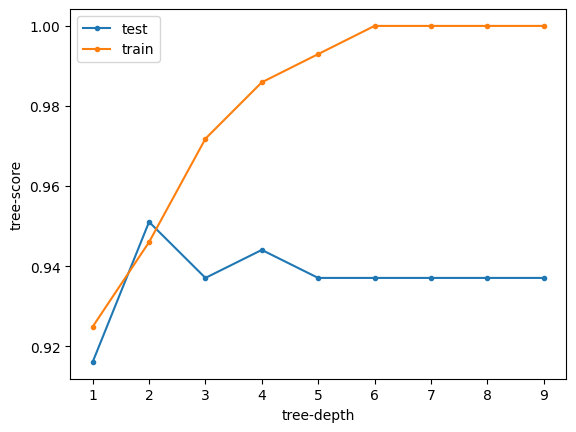

In [84]:
test_scores = list()
train_scores = list()

for i in range(1, 10):
    tree = DecisionTreeClassifier(max_depth=i, random_state=5)
    tree.fit(X_train, y_train)
    train_score = tree.score(X_train, y_train)
    test_score = tree.score(X_test, y_test)
    test_scores.append(test_score)
    train_scores.append(train_score)

    print(
        "Accuracy on the training subset: {:.3f} test subset: {:.3f}".format(
            train_score, test_score
        )
    )

plt.plot(range(1, 10), test_scores, ".-")
plt.plot(range(1, 10), train_scores, ".-")
plt.legend(["test", "train"])
plt.xlabel("tree-depth")
plt.ylabel("tree-score")

In [85]:
tree = DecisionTreeClassifier(max_depth=4)
tree.fit(X_train, y_train)

print("Accuracy on the training subset: {:.3f}".format(tree.score(X_train, y_train)))
print("Accuracy on the test subset: {:.3f}".format(tree.score(X_test, y_test)))

Accuracy on the training subset: 0.986
Accuracy on the test subset: 0.944


### Decision Tree visualiztion


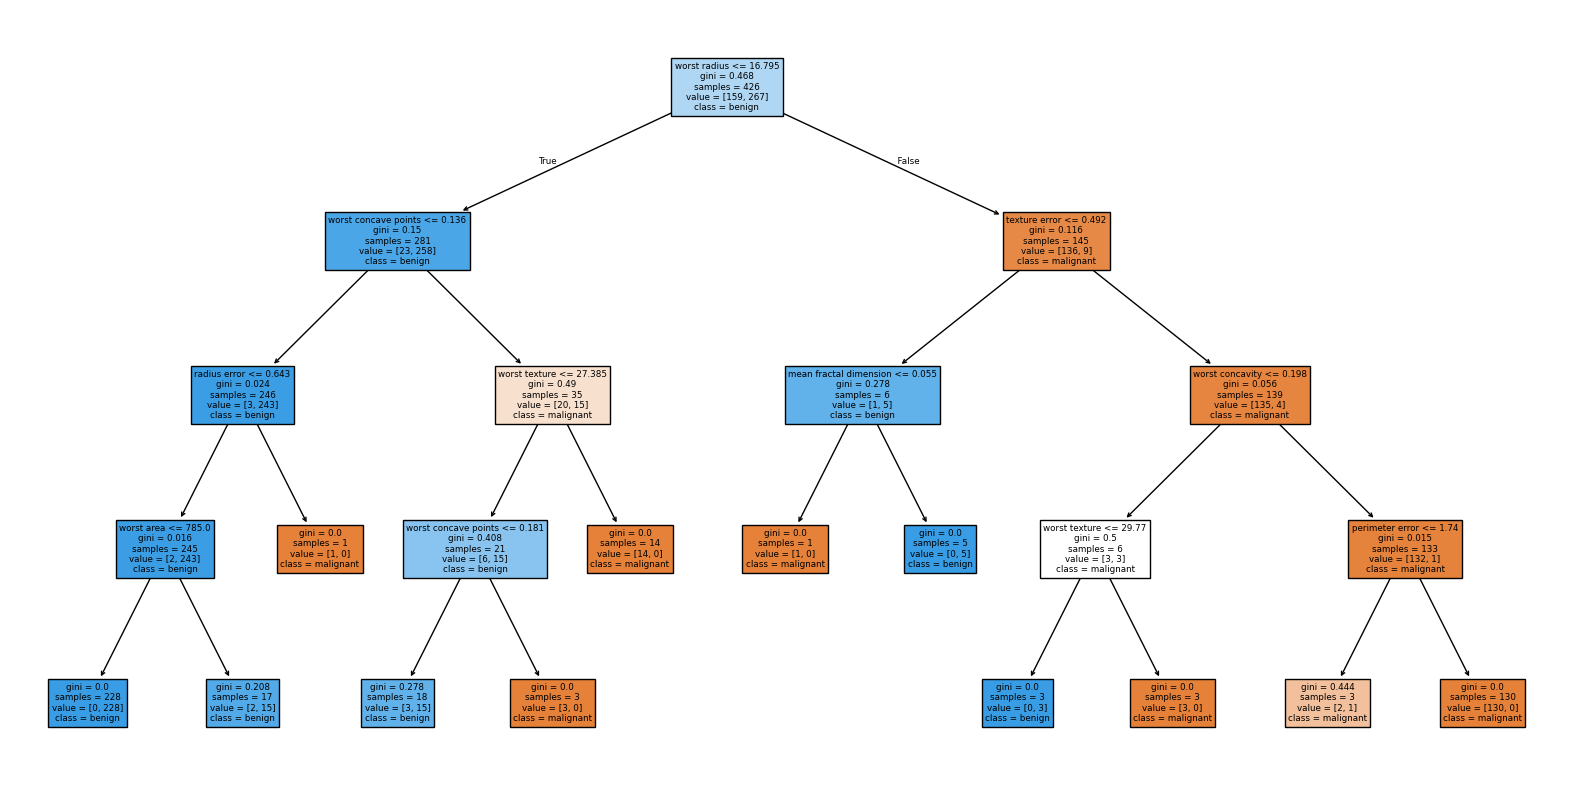

In [86]:
plt.figure(figsize=(20, 10))
plot_tree(
    tree,
    class_names=["malignant", "benign"],
    feature_names=cancer.feature_names,
    filled=True,
)
plt.show()

### feature_importances


In [87]:
print("Feature Importances:\n{}".format(tree.feature_importances_))

Feature Importances:
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.00879753 0.01034316 0.03930547
 0.00343964 0.         0.         0.         0.         0.
 0.         0.         0.74000718 0.06107999 0.         0.00231165
 0.         0.         0.01469973 0.12001565 0.         0.        ]


### feature_importances visualization


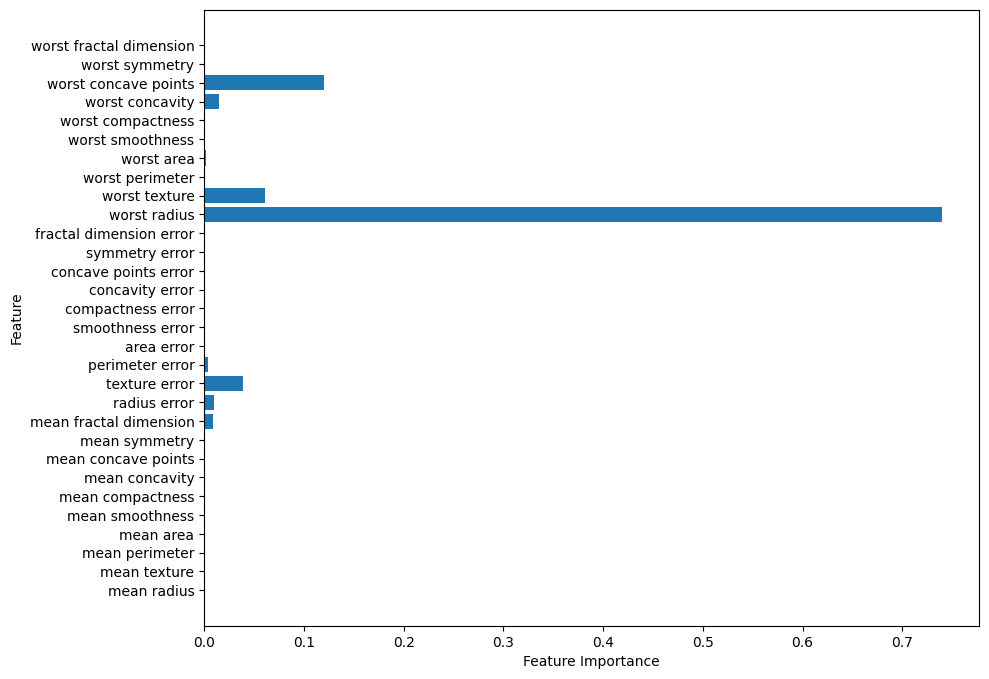

In [88]:
n_features = cancer.data.shape[1]
plt.figure(figsize=(10, 8))
plt.barh(range(n_features), tree.feature_importances_, align="center")
plt.yticks(np.arange(n_features), cancer.feature_names)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

---
# Random Forest 🌳🌳🌳🌳

Ensemble is a technique that builds a more powerful model by combining multiple machine learning models.

As we’ve seen earlier, a major drawback of decision trees is that they are unstable and tend to overfit the training data. `Random Forest` is a method that can address this issue. Essentially, a random forest is an **ensemble of multiple decision trees**, each slightly different from the others.

In [90]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## Building a Random Forest Model
To build a `Random Forest` model, you first need to decide **how many trees** you want to include. This is controlled by the **n_estimators** parameter in `RandomForestRegressor` or `RandomForestClassifier`.

For each tree, a `bootstrap` sample (a randomly drawn sample with replacement from the original data) is created. A decision tree is then trained using this bootstrap sample.

When constructing each tree, a random subset of features is considered at each split. The number of features to consider is controlled by the `max_features` parameter.

If `max_features` is set to the total number of features (n_features), the model considers **all** features at every split—meaning no randomness is introduced in feature selection.

On the other hand, setting max_features=1 means the tree doesn’t need to compare different features at each split—it simply finds the best threshold for a randomly selected feature.

### Key Parameters to Tune

- n_jobs: Number of CPU cores to use for training. (n_jobs=-1 uses all available cores for parallel processing.)
- n_estimators: Number of trees to build. (Generally, more trees lead to better performance, up to a point.)
- max_depth: Maximum depth of each tree, effectively controlling the level of pruning and model complexity.
- max_features: Controls randomness and feature selection.

- For classification tasks: `max_features` = sqrt(n_features) is the default.
- For regression tasks:`max_features` = log2(n_features) is often used.



## Breast Cancer Example

In [91]:
cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=0
)

In [93]:
forest = RandomForestClassifier(n_estimators=100, random_state=0)
forest.fit(X_train, y_train)

print("Accuracy on the training subset: {:.3f}".format(forest.score(X_train, y_train)))
print("Accuracy on the test subset: {:.3f}".format(forest.score(X_test, y_test)))

Accuracy on the training subset: 1.000
Accuracy on the test subset: 0.972


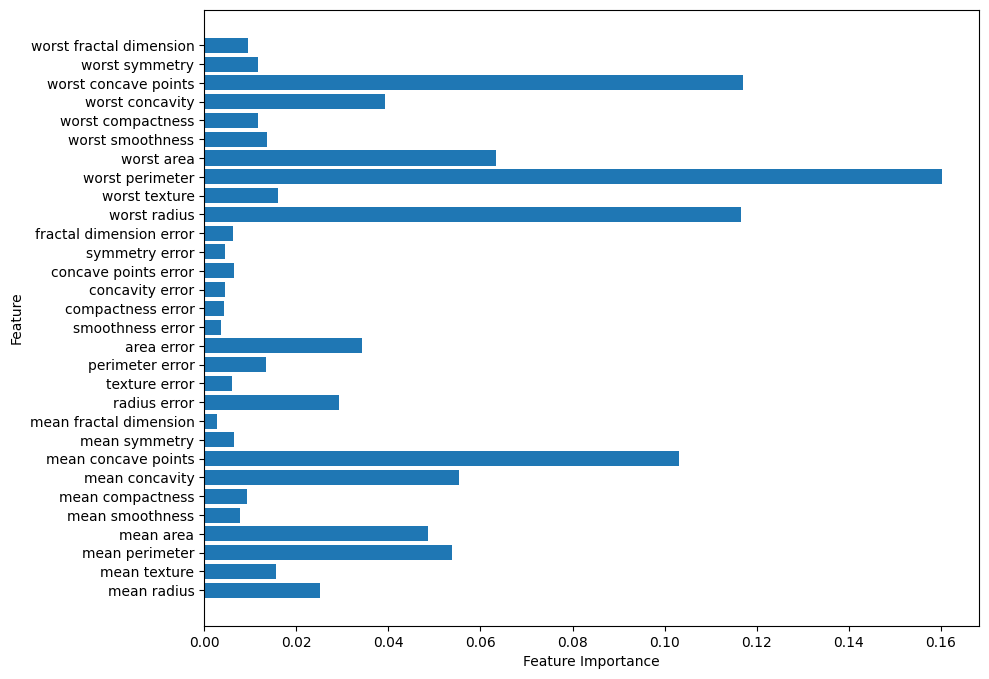

In [94]:
n_features = cancer.data.shape[1]
plt.figure(figsize=(10, 8))
plt.barh(range(n_features), forest.feature_importances_, align="center")
plt.yticks(np.arange(n_features), cancer.feature_names)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()